<a href="https://colab.research.google.com/github/adi-halder/python-ai-learning/blob/main/day5_better_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Python Day 5 - Trying Better AI Models
# BTech AI/ML | Vacation Learning

In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [7]:
# Load Apple stock data 2021-2026
df = yf.download("AAPL", start="2021-01-01", end="2026-01-01", auto_adjust=True)

# Flatten column names
df.columns = ["Close", "High", "Low", "Open", "Volume"]

# Create Target
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Create Features
df["Daily_Return"] = (df["Close"] - df["Open"]) / df["Open"] * 100
df["Price_Range"] = df["High"] - df["Low"]
df["Prev_Close"] = df["Close"].shift(1)
df["Prev_Return"] = df["Daily_Return"].shift(1)

# Remove missing rows
df = df.dropna()

print("Data ready!", df.shape)
print(df.tail(3))


[*********************100%***********************]  1 of 1 completed

Data ready! (1254, 10)
                 Close        High  ...  Prev_Close  Prev_Return
Date                                ...                         
2025-12-29  273.504089  274.103504  ...  273.144409    -0.277214
2025-12-30  272.824707  273.823772  ...  273.504089     0.392390
2025-12-31  271.605835  273.424141  ...  272.824707     0.098966

[3 rows x 10 columns]


In [8]:
# Define features and target
features = ["Open", "High", "Low", "Close", "Volume",
            "Daily_Return", "Price_Range", "Prev_Close", "Prev_Return"]
X = df[features]
Y = df["Target"]

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Train all 3 models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(max_iter=1000)

dt_model.fit(X_train, Y_train)
rf_model.fit(X_train, Y_train)
lr_model.fit(X_train, Y_train)

# Compare accuracy
dt_acc = accuracy_score(Y_test, dt_model.predict(X_test))
rf_acc = accuracy_score(Y_test, rf_model.predict(X_test))
lr_acc = accuracy_score(Y_test, lr_model.predict(X_test))

print("Decision Tree  :", round(dt_acc * 100, 2), "%")
print("Random Forest  :", round(rf_acc * 100, 2), "%")
print("Logistic Regr  :", round(lr_acc * 100, 2), "%")
print("\nBest model:", max([("Decision Tree", dt_acc), ("Random Forest", rf_acc), ("Logistic Regression", lr_acc)], key=lambda x: x[1])[0])

Decision Tree  : 45.42 %
Random Forest  : 46.61 %
Logistic Regr  : 49.8 %

Best model: Logistic Regression


In [9]:
# Add more powerful features
df["MA5"] = df["Close"].rolling(5).mean()    # 5-day average price
df["MA20"] = df["Close"].rolling(20).mean()  # 20-day average price
df["Volatility"] = df["Daily_Return"].rolling(5).std()  # how jumpy is the stock?

df = df.dropna()

# Retrain with new features
features = ["Open", "High", "Low", "Close", "Volume",
            "Daily_Return", "Price_Range", "Prev_Close",
            "Prev_Return", "MA5", "MA20", "Volatility"]

X = df[features]
Y = df["Target"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf_model2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model2.fit(X_train, Y_train)
acc = accuracy_score(Y_test, rf_model2.predict(X_test))
print("Improved Random Forest:", round(acc * 100, 2), "%")

Improved Random Forest: 48.99 %


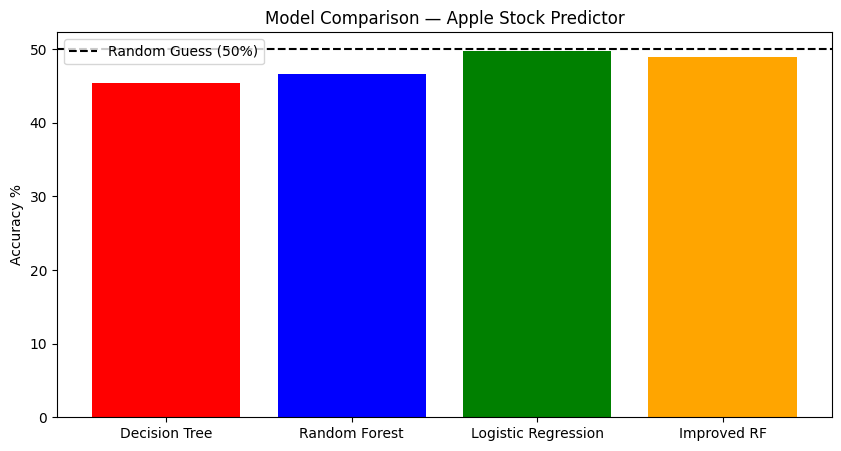

In [10]:
models = ["Decision Tree", "Random Forest", "Logistic Regression", "Improved RF"]
accuracies = [dt_acc*100, rf_acc*100, lr_acc*100, acc*100]

plt.figure(figsize=(10, 5))
plt.bar(models, accuracies, color=["red", "blue", "green", "orange"])
plt.axhline(y=50, color="black", linestyle="dashed", label="Random Guess (50%)")
plt.title("Model Comparison — Apple Stock Predictor")
plt.ylabel("Accuracy %")
plt.legend()
plt.show()